#<h1><center>Lab 1 - A1</center></h1>

##	REQUIREMENTS
1.	Source code (notebook) needs to be documented.
2.	Algorithms have to be tested for several parameter values (sufficient to clearly determine performance).
3.	Experiments must be performed for all available problem instances and results compared for diferent parameter settings.
4.	Results of the experiments need to be saved in output files, indicating solution quality, parameter values used, number of runs.
5.	A report should capture the following: problem definition, algorithm used (name, steps/pseudocode), parameter setting, comparative results of experiments, discussion of results.


## Knapsack Problem
- $n$ objects, each has a value ($v$) and a weight ($w$)
- Objective: the knapsack to contain max value without exceeding max weight $W$
 - $x_i=1$ means object $i$ is selected
 - $x_i=0$ means object $j$ is not selected

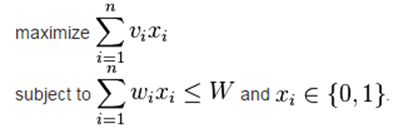


## WORK DURING THE LAB
1.	Exhaustive search: generate all possible binary strings of size N and print them on the screen. Test the code for different values of N.
2.	Read data for the knapsack problem.
3.	Generate a random solution for the knapsack problem and verify its quality.

**Points for the work during the lab: 25p**


In [2]:
import random

file_name = "knapsack-20.txt"
# Get all possible binary arrays of size n
def get_lists(n: int) -> list[list[int]]:
    if n == 0: return []
    if n == 1: return [[0], [1]]
    result = []
    for l in get_lists(n-1):
        result.append([0] + l)
        result.append([1] + l)
        
    return result

def load_data(file_name: str) -> "list[tuple[int, int]]":
  weights_and_values = []
  with open(file_name) as f:
    for line in f:
        parts = line.split() 
        if (len(parts) == 3):
            weight = int(parts[1])
            value = int(parts[2])
            weights_and_values.append((weight, value))
    
  return weights_and_values

def get_weight(file_name: str):
    with open(file_name) as f:
        lines = f.readlines() 
        return int(lines[-1].strip())

def check_random(): 
    data = load_data(file_name)
    all_combinations = get_lists(len(data)) 
    max_weight = get_weight(file_name)
    
    n = len(data)
    random_idx = random.randint(0, len(all_combinations) - 1)
    current_combination = all_combinations[random_idx]
    
    print(f"Checking combination index: {random_idx}")
    
    total_weight = 0
    total_value = 0
    
    for i in range(n):
        if current_combination[i] == 1:
            total_weight += data[i][0] # Weight
            total_value += data[i][1]  # Value
    
    if total_weight <= max_weight:
        return f"Found valid set! Weight: {total_weight}, Value: {total_value}"
    
    return f"Not a valid set! Weight: {total_weight}, Value: 0"

if __name__ == '__main__':
    print(get_lists(5))
    print(load_data(file_name))
    print(check_random())

[[0, 0, 0, 0, 0], [1, 0, 0, 0, 0], [0, 1, 0, 0, 0], [1, 1, 0, 0, 0], [0, 0, 1, 0, 0], [1, 0, 1, 0, 0], [0, 1, 1, 0, 0], [1, 1, 1, 0, 0], [0, 0, 0, 1, 0], [1, 0, 0, 1, 0], [0, 1, 0, 1, 0], [1, 1, 0, 1, 0], [0, 0, 1, 1, 0], [1, 0, 1, 1, 0], [0, 1, 1, 1, 0], [1, 1, 1, 1, 0], [0, 0, 0, 0, 1], [1, 0, 0, 0, 1], [0, 1, 0, 0, 1], [1, 1, 0, 0, 1], [0, 0, 1, 0, 1], [1, 0, 1, 0, 1], [0, 1, 1, 0, 1], [1, 1, 1, 0, 1], [0, 0, 0, 1, 1], [1, 0, 0, 1, 1], [0, 1, 0, 1, 1], [1, 1, 0, 1, 1], [0, 0, 1, 1, 1], [1, 0, 1, 1, 1], [0, 1, 1, 1, 1], [1, 1, 1, 1, 1]]
[(91, 29), (60, 65), (61, 71), (9, 60), (79, 45), (46, 71), (19, 22), (57, 97), (8, 6), (84, 91), (20, 57), (72, 60), (32, 49), (31, 89), (28, 2), (81, 30), (55, 90), (43, 25), (100, 82), (27, 19)]
Checking combination index: 884748
Found valid set! Weight: 333, Value: 352


##	ASSIGNMENT A1
1.	Implement a random search method for the knapsack problem.
 1.	From k random solutions, the method should return the best one.
 1.	Test the method for different values of k.
 1.	Perform experiments for knapsack instances of size 20 and 200.
1.	Submit source code and report.

**Deadline to submit A1: Lab 2**
**Points for A1: 25p**


### Imports and Global Variables

In [1]:
import random
import time
import os

FILES_TO_TEST = [
    {"name": "knapsack-20.txt", "size": 20},
    {"name": "knapsack-200.txt", "size": 200}
]

K_VALUES = [10, 100, 1000, 10000, 50000]



### Helpers

In [2]:
def load_data(file_name: str) -> tuple[list[tuple[int, int]], int]:
    """
    Loads weights, values, and max capacity from the file.
    Returns a tuple: (list_of_items, max_capacity)
    """
    items = []
    capacity = 0

    if not os.path.exists(file_name):
        print(f"Error: File '{file_name}' not found.")
        return [], 0

    with open(file_name) as f:
        lines = f.readlines()

        for line in lines[:-1]:
            parts = line.strip().split()
            if len(parts) >= 3:
                weight = int(parts[1])
                value = int(parts[2])
                items.append((weight, value))

        try:
            capacity = int(lines[-1].strip())
        except ValueError:
            print("Error parsing capacity from last line.")

    return items, capacity


def evaluate_solution(
    solution: list[int], items: list[tuple[int, int]], max_weight: int
) -> tuple[int, int]:
    """
    Calculates total weight and value of a solution.
    Returns (weight, value).
    If weight > max_weight, value is set to 0 (penalty for infeasibility).
    """
    total_weight = 0
    total_value = 0

    for i, is_included in enumerate(solution):
        if is_included == 1:
            total_weight += items[i][0]
            total_value += items[i][1]

    # Check feasibility
    if total_weight > max_weight:
        return total_weight, 0  # Infeasible solution

    return total_weight, total_value


def get_random_solution(n: int) -> list[int]:
    """
    Generates a single random binary list of length n.
    This replaces the inefficient get_lists recursive function.
    """
    return [random.randint(0, 1) for _ in range(n)]



### Core Algorithm

In [3]:
def random_search(items: list[tuple[int, int]], max_weight: int, k: int) -> dict:
    """
    Performs random search for k iterations.
    Returns the best found solution and statistics.
    """
    n = len(items)
    best_value = -1
    best_weight = 0
    best_solution = []

    for _ in range(k):
        candidate = get_random_solution(n)

        w, v = evaluate_solution(candidate, items, max_weight)

        if v > best_value:
            best_value = v
            best_weight = w
            best_solution = candidate

    return {"value": best_value, "weight": best_weight, "solution": best_solution}



### Running Experiments

In [ ]:
def run_experiments(num_runs=10):
    """
    Runs the random search algorithm multiple times for each parameter setting
    to ensure statistical reliability, and saves the results to an output file.
    """
    # Open file and write the header including the Number of Runs
    with open("output.md", "w") as f:
        f.write(f"| {'Instance':<20} | {'Runs':<6} | {'K (Iterations)':<15} | {'Best Value (Max)':<18} | {'Avg Best Value':<15} | {'Avg Time (s)':<12} |\n")
        f.write("|---|---|---|---|---|---|\n")

    for file_info in FILES_TO_TEST:
        filename = file_info["name"]
        items, capacity = load_data(filename)

        if not items:
            with open("output.md", "a") as f:
                f.write(f"| {filename} | {'N/A':<6} | {'N/A':<15} | {'Error: File not found':<18} | {'N/A':<15} | {'N/A':<12} |\n")
            continue

        for k in K_VALUES:
            best_overall_value = -1
            sum_best_values = 0
            total_time = 0

            # Perform multiple independent runs for the same k
            for run in range(num_runs):
                start_time = time.time()
                result = random_search(items, capacity, k)
                elapsed = time.time() - start_time
                
                total_time += elapsed
                sum_best_values += result['value']
                
                if result['value'] > best_overall_value:
                    best_overall_value = result['value']

            # Calculate averages across the runs
            avg_value = sum_best_values / num_runs
            avg_time = total_time / num_runs

            # Save results of the experiments to the output file
            with open("output.md", "a") as f:
                f.write(
                    f"| {filename:<20} | {num_runs:<6} | {k:<15} | {best_overall_value:<18} | {avg_value:<15.2f} | {avg_time:<12.4f} |\n"
                )

if __name__ == "__main__":
    # You can change the number of runs here
    run_experiments(num_runs=10)

| Instance             | K        | Best Value   | Weight     | Time (s)   |
|---|---|---|---|---|
| knapsack-20.txt      | 10       | 531          | 456        | 0.0001 |
| knapsack-20.txt      | 100      | 623          | 522        | 0.0008 |
| knapsack-20.txt      | 1000     | 725          | 513        | 0.0086 |
| knapsack-20.txt      | 10000    | 754          | 501        | 0.0861 |
| knapsack-20.txt      | 50000    | 757          | 493        | 0.4303 |
| knapsack-200.txt     | 10       | 93028        | 109428     | 0.0009 |
| knapsack-200.txt     | 100      | 94533        | 110033     | 0.0082 |
| knapsack-200.txt     | 1000     | 96934        | 112434     | 0.0853 |
| knapsack-200.txt     | 10000    | 97141        | 112441     | 0.8284 |
| knapsack-200.txt     | 50000    | 97187        | 112587     | 4.1320 |